# Data Preparation
This notebook processes `job_listings.json` and creates 3 tables connected by `job_id`:

1. **job_descriptions.csv**: Text information for each job (title, summary, tasks)
2. **job_skills.csv**: Skills extracted per job (hard and soft skills)
3. **job_balancer.csv**: Balancing information for ML (num_candidates, weight, frequency_group)

## Applied Transformations:
- Lowercase in all texts
- Includes hard skills (type_skill=0) and soft skills (type_skill=1)
- No cleaning of special characters
- No removal of junior/senior
- TASKS parsed correctly (without dictionary format)
- Column 'description' removed (mostly empty)

## 1. Load Data

In [1]:
import json
import pandas as pd
import numpy as np
import ast
import os
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load job_listings.json
print("Loading job_listings.json")
with open('../Data/job_listings.json', 'r', encoding='utf-8') as f:
    job_listings = json.load(f)

print(f"{len(job_listings):,} jobs loaded")

# Load training data for balancing
print("\nLoading training data")
y_train = pd.read_csv('../Data/y_train_SwJNMSu.csv')

print(f"{len(y_train):,} records in y_train")
print(f"   Unique jobs in y_train: {y_train['job_id'].nunique():,}")

Loading job_listings.json
21,917 jobs loaded

Loading training data
15,882 records in y_train
   Unique jobs in y_train: 7,030


## 2. Table 1: job_descriptions

Extracts text information for each job:
- job_id
- title
- summary
- tasks (parsed from dictionary format)

**Transformation**: Apply lowercase to all text
**Note**: 'description' column removed (mostly empty and not very useful)

In [3]:
def extract_section(job_text, section_name):
    """
    Extracts the content of a specific section from the job text.
    Applies lowercase.
    """
    header = section_name + "\n"
    if header not in job_text:
        return ""
    
    # Find start of the section
    start_idx = job_text.find(header) + len(header)
    
    # Find end of the section (start of the next section or end of text)
    remaining_text = job_text[start_idx:]
    
    # Search for the next section break (double line break followed by UPPERCASE)
    sections = ["\n\nTITLE", "\n\nSUMMARY", "\n\nDESCRIPTION", "\n\nSKILLS", 
                "\n\nTASKS", "\n\nLANGUAGES", "\n\nCERTIFICATIONS", "\n\nCOURSES"]
    
    end_idx = len(remaining_text)
    for next_section in sections:
        idx = remaining_text.find(next_section)
        if idx != -1 and idx < end_idx:
            end_idx = idx
    
    content = remaining_text[:end_idx].strip()
    
    # Apply lowercase
    return content.lower()

def extract_dict_list_section(job_text, section_name):
    """
    Extracts a section that contains a list of dictionaries (like TASKS).
    Parses the dictionaries and extracts only the 'name' field from each one.
    Returns a string with the names separated by ' | '.
    Applies lowercase.
    """
    header = section_name + "\n"
    if header not in job_text:
        return ""
    
    # Find start of the section
    start_idx = job_text.find(header) + len(header)
    remaining_text = job_text[start_idx:]
    
    # Search for the next section break
    sections = ["\n\nTITLE", "\n\nSUMMARY", "\n\nDESCRIPTION", "\n\nSKILLS", 
                "\n\nTASKS", "\n\nLANGUAGES", "\n\nCERTIFICATIONS", "\n\nCOURSES"]
    
    end_idx = len(remaining_text)
    for next_section in sections:
        idx = remaining_text.find(next_section)
        if idx != -1 and idx < end_idx:
            end_idx = idx
    
    content = remaining_text[:end_idx].strip()
    
    if not content:
        return ""
    
    # Parse the dictionaries and extract the names
    names = []
    for line in content.split('\n'):
        line = line.strip()
        if line.startswith('- '):
            dict_text = line[2:]
            try:
                item_dict = ast.literal_eval(dict_text)
                name = str(item_dict.get('name', '')).strip()
                if name:
                    # Apply lowercase
                    names.append(name.lower())
            except:
                continue
    
    # Join all names with separator
    return ' | '.join(names)

In [4]:
# Build job_descriptions table
descriptions_data = []

for job_id, job_text in job_listings.items():
    descriptions_data.append({
        'job_id': job_id,
        'title': extract_section(job_text, 'TITLE'),
        'summary': extract_section(job_text, 'SUMMARY'),
        'tasks': extract_dict_list_section(job_text, 'TASKS')  # Parse TASKS correctly
    })

job_descriptions = pd.DataFrame(descriptions_data)

print(f"\njob_descriptions table created: {job_descriptions.shape}")
print(f"\nColumns: {job_descriptions.columns.tolist()}")

# Statistics
print(f"\nAvailable content:")
print(f"   - Jobs with title: {(job_descriptions['title'] != '').sum():,}")
print(f"   - Jobs with summary: {(job_descriptions['summary'] != '').sum():,}")
print(f"   - Jobs with tasks: {(job_descriptions['tasks'] != '').sum():,}")

print(f"\nNote: 'description' column removed (mostly empty)")
print(f"   TASKS now contains only parsed names, without dictionary format")

display(job_descriptions.head(10))


job_descriptions table created: (21917, 4)

Columns: ['job_id', 'title', 'summary', 'tasks']

Available content:
   - Jobs with title: 21,913
   - Jobs with summary: 21,545
   - Jobs with tasks: 12,292

Note: 'description' column removed (mostly empty)
   TASKS now contains only parsed names, without dictionary format


,job_id,title,summary,tasks
0,0,qa intégration / data analyst - salesforces s...,responsabilités :\nassurer la qualité des do...,assurer la qualité des données intégrées |...
1,1,ingénieur système,nous recherchons un ingénieur système pour n...,administrer des serveurs middleware | administ...
2,2,testeur qa automatisation cypress,vous avez au moins une première expérience s...,approche axée sur les solutions | assister le...
3,3,ingénieur support n3 ip - paris,dans le cadre de cette mission :\nvous garanti...,apporter un support technique sur le fonctionn...
4,4,business analyst moa front,nous recherchons un (e) consultant(e) ayant un...,accompagnement de la maitrise d’œuvre sur la r...
5,5,business analyst sap s/4,notre client est à la recherche de son procha...,animer la communauté d'utilisateurs | capacit...
6,6,salesforce marketing cloud product owner,mission / freelance / paris / salesforce marke...,
7,7,responsable sécurité opérationnel,opportunité freelance - responsable sécurite...,animer la mise en œuvre des politiques\nopéra...
8,8,architecte d'entreprise data bi,poste d'architecte d'entreprise pour rejoindre...,conduite des\nétudes d'architecture impliquan...
9,9,ingénieur.e qa web / mobile - (haute-savoie -...,au sein de l’équipe d’assistance à maitrise ...,"amélioration des\nprocessus de recette, docum..."


## 3. Table 2: job_skills

Extracts all skills (hard and soft) for each job:
- job_id
- skill (skill name in lowercase)
- type_skill (0 = hard, 1 = soft)

**Note**: Jobs without skills do not appear in this table

In [5]:
def extract_skills(job_text):
    """
    Extracts skills from the job text.
    Returns list of dictionaries with {name, type}.
    Does NOT apply lowercase at this stage to avoid breaking parsing.
    """
    # Extract SKILLS section without lowercase
    header = "SKILLS\n"
    if header not in job_text:
        return []
    
    # Find start of the section
    start_idx = job_text.find(header) + len(header)
    remaining_text = job_text[start_idx:]
    
    # Search for the next section break
    sections = ["\n\nTITLE", "\n\nSUMMARY", "\n\nDESCRIPTION", "\n\nSKILLS", 
                "\n\nTASKS", "\n\nLANGUAGES", "\n\nCERTIFICATIONS", "\n\nCOURSES"]
    
    end_idx = len(remaining_text)
    for next_section in sections:
        idx = remaining_text.find(next_section)
        if idx != -1 and idx < end_idx:
            end_idx = idx
    
    skills_content = remaining_text[:end_idx].strip()
    
    if not skills_content:
        return []
    
    skills = []
    
    # Each skill is on a line starting with "- "
    for line in skills_content.split('\n'):
        line = line.strip()
        if line.startswith('- '):
            # Remove "- " and parse the dictionary
            dict_text = line[2:]
            try:
                skill_dict = ast.literal_eval(dict_text)
                # Apply lowercase to the name
                skill_name = str(skill_dict.get('name', '')).lower()
                skill_type = str(skill_dict.get('type', '')).lower()
                
                if skill_name and skill_type:
                    skills.append({
                        'name': skill_name,
                        'type': skill_type
                    })
            except:
                continue
    
    return skills

In [6]:
# Build job_skills table
print("Building job_skills table...")

skills_data = []

for job_id, job_text in job_listings.items():
    skills_list = extract_skills(job_text)
    
    for skill in skills_list:
        # Map type to numeric value
        type_skill = 0 if skill['type'] == 'hard' else 1
        
        skills_data.append({
            'job_id': job_id,
            'skill': skill['name'],
            'type_skill': type_skill
        })

job_skills = pd.DataFrame(skills_data)

print(f"\njob_skills table created: {job_skills.shape}")

if len(job_skills) > 0:
    print(f"\nColumns: {job_skills.columns.tolist()}")
    
    # Statistics
    print(f"\nSkills distribution:")
    print(f"   - Total skills: {len(job_skills):,}")
    print(f"   - Unique jobs with skills: {job_skills['job_id'].nunique():,}")
    print(f"   - Unique skills: {job_skills['skill'].nunique():,}")
    print(f"\n   By type:")
    type_counts = job_skills['type_skill'].value_counts().sort_index()
    print(f"   - Hard skills (0): {type_counts.get(0, 0):,}")
    print(f"   - Soft skills (1): {type_counts.get(1, 0):,}")
    
    display(job_skills.head(15))
else:
    print("No skills")

Building job_skills table...

job_skills table created: (147376, 3)

Columns: ['job_id', 'skill', 'type_skill']

Skills distribution:
   - Total skills: 147,376
   - Unique jobs with skills: 12,992
   - Unique skills: 19,941

   By type:
   - Hard skills (0): 136,780
   - Soft skills (1): 10,596


,job_id,skill,type_skill
0,0,salesforce sales cloud,0
1,1,administration linux,0
2,1,administration windows,0
3,1,apache tomcat,0
4,1,azure,0
5,1,azure devops server,0
6,1,devops,0
7,1,google cloud platform,0
8,1,virtualisation,0
9,1,vmware,0


In [7]:
job_skills

,job_id,skill,type_skill
0,0,salesforce sales cloud,0
1,1,administration linux,0
2,1,administration windows,0
3,1,apache tomcat,0
4,1,azure,0
...,...,...,...
147371,23477,jira,0
147372,23477,confluence,0
147373,23477,jira,0
147374,23477,sql,0


In [8]:
# Top 10 skills 
print("\nTop 10 Hard Skills:")
hard_skills = job_skills[job_skills['type_skill'] == 0]
top_hard = hard_skills['skill'].value_counts().head(10)
for i, (skill, count) in enumerate(top_hard.items(), 1):
    print(f"   {i}. {skill}: {count:,}")

print("\nTop 10 Soft Skills:")
soft_skills = job_skills[job_skills['type_skill'] == 1]
top_soft = soft_skills['skill'].value_counts().head(10)
for i, (skill, count) in enumerate(top_soft.items(), 1):
    print(f"   {i}. {skill}: {count:,}")


Top 10 Hard Skills:
   1. sql: 2,026
   2. java: 2,020
   3. agile: 1,982
   4. python: 1,673
   5. jira: 1,667
   6. linux: 1,402
   7. devops: 1,196
   8. git: 1,174
   9. angular: 1,157
   10. azure: 1,049

Top 10 Soft Skills:
   1. communication: 627
   2. esprit d'analyse: 575
   3. agilité: 547
   4. rigueur: 545
   5. autonomie: 411
   6. organisation: 368
   7. autonome: 309
   8. travail d'équipe: 287
   9. gestion de projets: 258
   10. rigoureux: 255


## 4. Table 3: job_balancer

Creates balancing information for each job:
- job_id
- num_candidates (number of candidates who applied)
- weight (weight = 1/sqrt(num_candidates))
- frequency_group (high: >100, medium: 10-100, low: <10)

In [9]:
# Count occurrences in y_train
job_counts = y_train['job_id'].value_counts().reset_index()
job_counts.columns = ['job_id', 'num_candidates']

# Calculate weight: 1/sqrt(num_candidates)
job_counts['weight'] = 1 / np.sqrt(job_counts['num_candidates'])

# Classify into frequency groups
def classify_frequency(num_candidates):
    if num_candidates > 100:
        return 'high'
    elif num_candidates >= 10:
        return 'medium'
    else:
        return 'low'

job_counts['frequency_group'] = job_counts['num_candidates'].apply(classify_frequency)

job_balancer = job_counts[['job_id', 'num_candidates', 'weight', 'frequency_group']]

print(f"\njob_balancer table created: {job_balancer.shape}")
print(f"\nColumns: {job_balancer.columns.tolist()}")

# Statistics
print(f"\nBalancing statistics:")
print(f"   - Unique jobs: {len(job_balancer):,}")
print(f"   - Candidates per job (average): {job_balancer['num_candidates'].mean():.2f}")
print(f"   - Candidates per job (median): {job_balancer['num_candidates'].median():.0f}")
print(f"   - Average weight: {job_balancer['weight'].mean():.4f}")
print(f"\n   Frequency distribution:")
freq_dist = job_balancer['frequency_group'].value_counts()
for group in ['high', 'medium', 'low']:
    count = freq_dist.get(group, 0)
    pct = (count / len(job_balancer) * 100) if len(job_balancer) > 0 else 0
    print(f"   - {group}: {count:,} ({pct:.1f}%)")

display(job_balancer.head(10))


job_balancer table created: (7030, 4)

Columns: ['job_id', 'num_candidates', 'weight', 'frequency_group']

Balancing statistics:
   - Unique jobs: 7,030
   - Candidates per job (average): 2.26
   - Candidates per job (median): 1
   - Average weight: 0.8232

   Frequency distribution:
   - high: 0 (0.0%)
   - medium: 179 (2.5%)
   - low: 6,851 (97.5%)


,job_id,num_candidates,weight,frequency_group
0,518,28,0.188982,medium
1,41,28,0.188982,medium
2,1620,26,0.196116,medium
3,155,24,0.204124,medium
4,1460,24,0.204124,medium
5,89,23,0.208514,medium
6,50,23,0.208514,medium
7,85,22,0.213201,medium
8,332,22,0.213201,medium
9,457,21,0.218218,medium


## 5. Visualizations

Charts to understand data distribution.

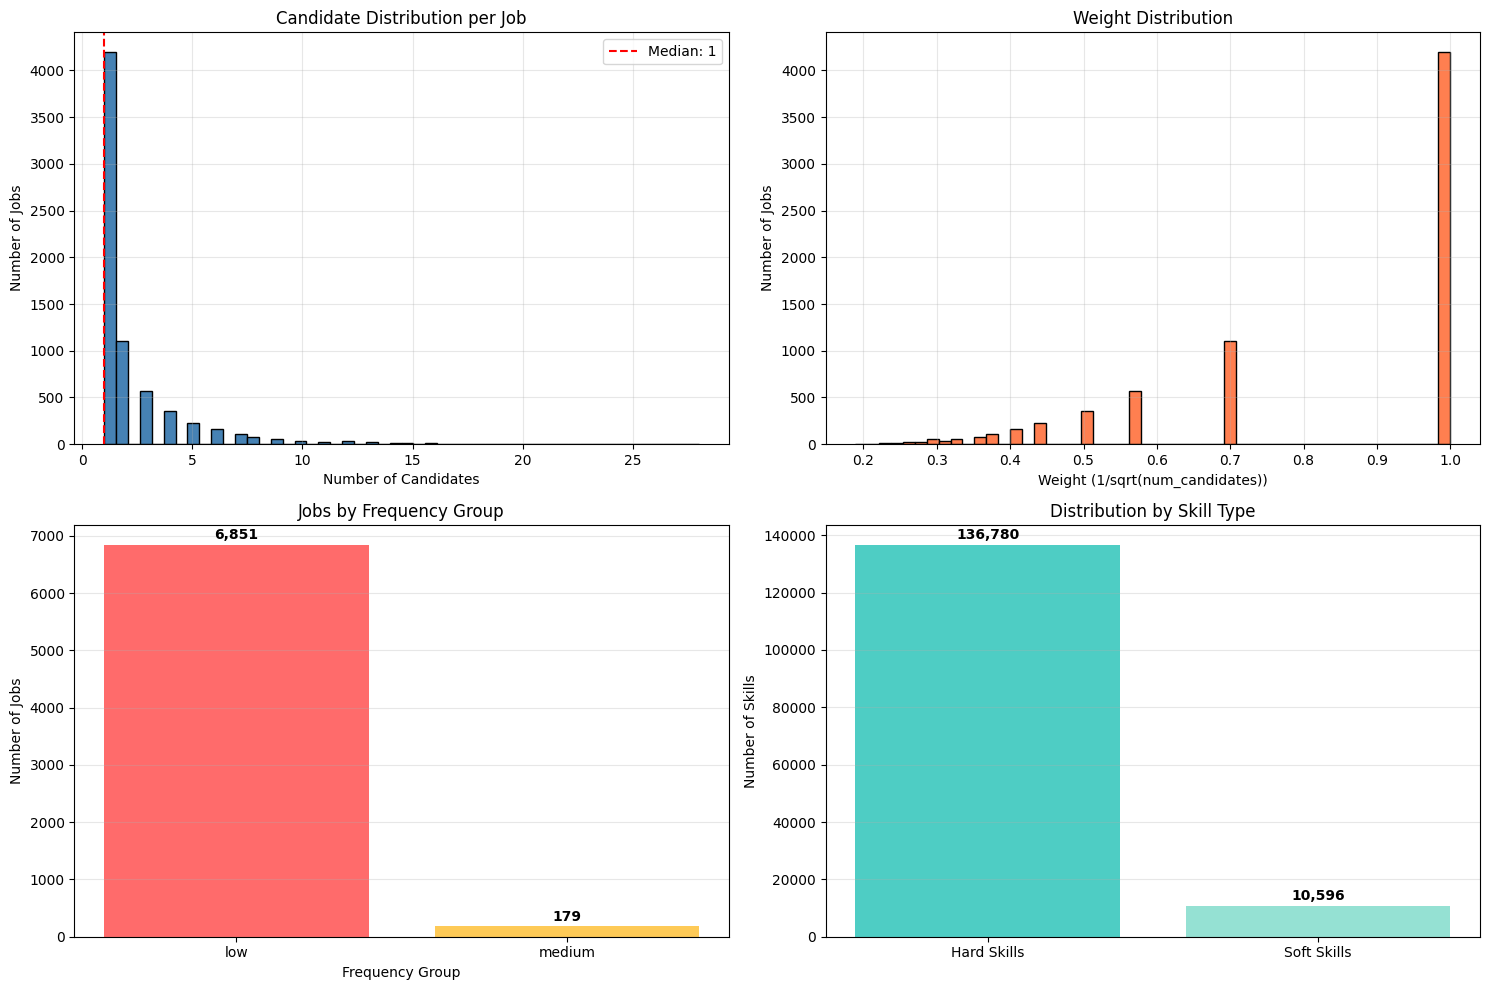

In [10]:
# Visualization 1: Candidate distribution per job
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of num_candidates
axes[0, 0].hist(job_balancer['num_candidates'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Number of Candidates')
axes[0, 0].set_ylabel('Number of Jobs')
axes[0, 0].set_title('Candidate Distribution per Job')
axes[0, 0].axvline(job_balancer['num_candidates'].median(), color='red', 
                   linestyle='--', label=f'Median: {job_balancer["num_candidates"].median():.0f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Weight distribution
axes[0, 1].hist(job_balancer['weight'], bins=50, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Weight (1/sqrt(num_candidates))')
axes[0, 1].set_ylabel('Number of Jobs')
axes[0, 1].set_title('Weight Distribution')
axes[0, 1].grid(alpha=0.3)

# 3. Frequency groups
freq_counts = job_balancer['frequency_group'].value_counts()
axes[1, 0].bar(freq_counts.index, freq_counts.values, color=['#ff6b6b', '#feca57', '#48dbfb'])
axes[1, 0].set_xlabel('Frequency Group')
axes[1, 0].set_ylabel('Number of Jobs')
axes[1, 0].set_title('Jobs by Frequency Group')
axes[1, 0].grid(axis='y', alpha=0.3)

# Add values to bars
for i, (group, count) in enumerate(freq_counts.items()):
    axes[1, 0].text(i, count + 50, f'{count:,}', ha='center', va='bottom', fontweight='bold')

# 4. Skills by type
type_counts = job_skills['type_skill'].value_counts().sort_index()
type_labels = ['Hard Skills', 'Soft Skills']
axes[1, 1].bar(type_labels, type_counts.values, color=['#4ecdc4', '#95e1d3'])
axes[1, 1].set_ylabel('Number of Skills')
axes[1, 1].set_title('Distribution by Skill Type')
axes[1, 1].grid(axis='y', alpha=0.3)

# Add values to bars
for i, count in enumerate(type_counts.values):
    axes[1, 1].text(i, count + 1000, f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

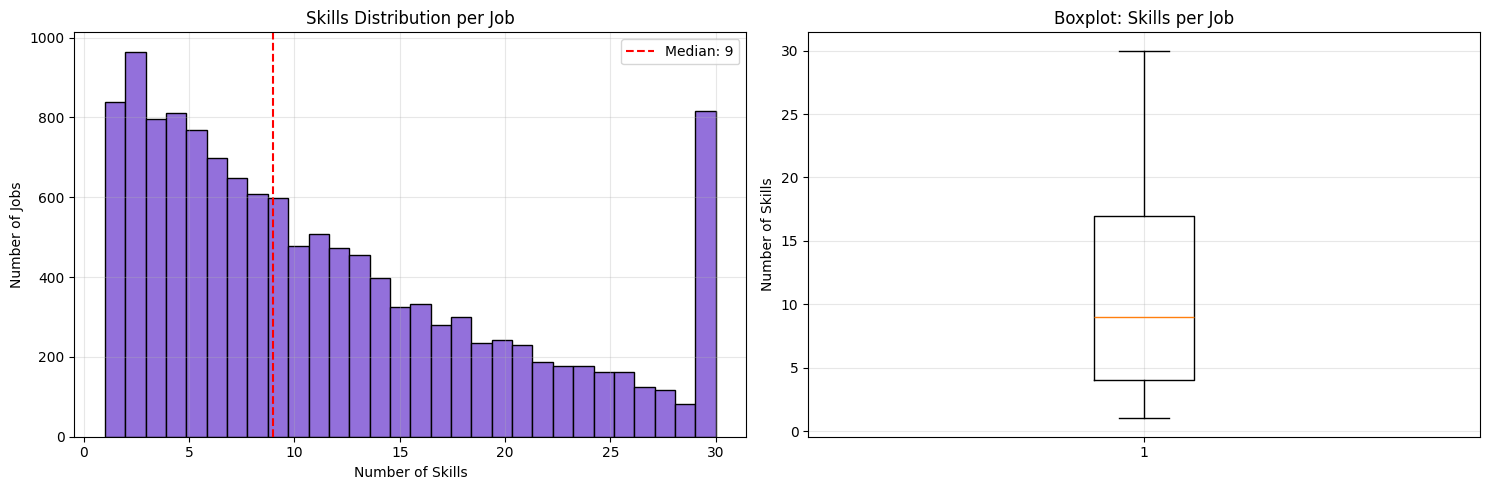

In [11]:
# Visualization 2: Skills per job
skills_per_job = job_skills.groupby('job_id').size()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(skills_per_job, bins=30, color='mediumpurple', edgecolor='black')
axes[0].set_xlabel('Number of Skills')
axes[0].set_ylabel('Number of Jobs')
axes[0].set_title('Skills Distribution per Job')
axes[0].axvline(skills_per_job.median(), color='red', 
                linestyle='--', label=f'Median: {skills_per_job.median():.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(skills_per_job, vert=True)
axes[1].set_ylabel('Number of Skills')
axes[1].set_title('Boxplot: Skills per Job')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Export Tables

We save the 3 tables in the `Data/job_listing_feature/` folder

In [12]:
# Create output folder
output_dir = '../Data/job_listing_feature'
os.makedirs(output_dir, exist_ok=True)

print(f"Output folder: {output_dir}")
print(f"\nExporting tables...")

# Export the 3 tables
job_descriptions.to_csv(f'{output_dir}/job_descriptions.csv', index=False, encoding='utf-8')
print(f"job_descriptions.csv - {job_descriptions.shape[0]:,} rows")

job_skills.to_csv(f'{output_dir}/job_skills.csv', index=False, encoding='utf-8')
print(f"job_skills.csv - {job_skills.shape[0]:,} rows")

job_balancer.to_csv(f'{output_dir}/job_balancer.csv', index=False, encoding='utf-8')
print(f"job_balancer.csv - {job_balancer.shape[0]:,} rows")

Output folder: ../Data/job_listing_feature

Exporting tables...
job_descriptions.csv - 21,917 rows
job_skills.csv - 147,376 rows
job_balancer.csv - 7,030 rows
